# Routing Coefficient Optimization

The standard beam-search scoring function treats all log-space terms equally:

```
score = 1·Σlog(CZ) + 1·Σlog(readout) + 1·Σlog(T1_surv) + 1·Σlog(T2_surv)
```

This notebook finds **scalar weights [w_cz, w_ro, w_t1, w_t2]** that maximise measured Z-fidelity
for a W-state circuit, using a low-shot QPU budget.

**Workflow:**
1. Sample 500 weight vectors → run beam search → collect unique chains (pure classical, no QPU)
2. Visualise how chain selection changes across the weight landscape
3. Submit one Z-basis job per unique chain (250 shots each) → measure fidelity
4. Identify optimal weights; optionally refine with Nelder-Mead (≤15 extra QPU calls)
5. Cross-validate on N ∈ {10, 15, 20, 25} and compare vs equal-weight baseline

In [65]:
# ── Experiment parameters ───────────────────────────────────────────────────
N_QUBITS         = 30     # optimise for this qubit count — beyond prior equal-weight experiments
EVAL_SHOTS       = 500    # shots per circuit
BEAM_WIDTH       = 100    # beam search width
N_WEIGHT_SAMPLES = 1000   # random weight vectors to explore
NM_RESTARTS      = 3      # Nelder-Mead restarts from top-K grid candidates
NM_MAXITER       = 30     # iterations per restart
RESULTS_FILE     = 'routing_coefficient_optimization_results_emerald_2.json'

## 1. Connect to IQM Resonance

In [66]:
import os, math, json, datetime
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from scipy.optimize import minimize
from qiskit import transpile
from iqm.qiskit_iqm import IQMProvider
from iqm.qubit_selector.qubit_selector import CalibrationDataManager
from iqm.qubit_selector.qiskit_utils import get_circuit, CircuitType

secret_path = Path().cwd() / '.secrets' / 'iqm_api_key'
api_token = secret_path.read_text().strip() if secret_path.exists() \
            else input('IQM Resonance API token: ').strip()
os.environ['IQM_TOKEN'] = api_token

provider = IQMProvider('https://resonance.meetiqm.com', quantum_computer='emerald')
backend  = provider.get_backend()
print(f'Connected to: {backend.name}  ({backend.num_qubits} qubits)')

Connected to: IQMBackend  (54 qubits)


## 2. Load calibration data

In [67]:
cal = CalibrationDataManager().get_calibration_fidelities(backend)

cz_raw      = cal.get('CZ', {})
readout_raw = cal.get('readout', {})
t1_raw      = cal.get('t1', {})
t2_raw      = cal.get('t2', {})

def _parse_pair(fid_dict):
    out = {}
    for k, v in fid_dict.items():
        try:
            names = eval(k)
            idxs  = tuple(backend.qubit_name_to_index(n) for n in names)
            out[frozenset(idxs)] = float(v)
        except Exception:
            pass
    return out

def _parse_qubit(raw):
    out = {}
    for name, v in raw.items():
        try:
            out[backend.qubit_name_to_index(name)] = float(v)
        except Exception:
            pass
    return out

cz_fid = _parse_pair(cz_raw)
ro_fid = _parse_qubit(readout_raw)
t1_us  = _parse_qubit(t1_raw)
t2_us  = _parse_qubit(t2_raw)

cz_durations = []
if 'cz' in backend.target:
    for qargs, props in backend.target['cz'].items():
        if props and props.duration:
            cz_durations.append(props.duration)
mean_cz_ns = np.mean(cz_durations) * 1e9 if cz_durations else 80.0

def t1_survival(phys, wait_ns, default_t1_us=200.0):
    t1_ns = t1_us.get(phys, default_t1_us) * 1e3
    return float(np.exp(-wait_ns / t1_ns))

def t2_survival(phys, wait_ns, default_t2_us=100.0):
    t2_ns = t2_us.get(phys, default_t2_us) * 1e3
    return float(np.exp(-wait_ns / t2_ns))

print(f'CZ fidelities: {len(cz_fid)} edges | Readout: {len(ro_fid)} qubits')
print(f'T1: {len(t1_us)} qubits | T2: {len(t2_us)} qubits')
print(f'Mean CZ gate duration: {mean_cz_ns:.1f} ns')

CZ fidelities: 81 edges | Readout: 54 qubits
T1: 54 qubits | T2: 53 qubits
Mean CZ gate duration: 80.0 ns


## 3. Build topology + helper functions

In [68]:
edges_list = list(backend.coupling_map.get_edges())
adj = {}
for u, v in edges_list:
    adj.setdefault(u, set()).add(v)
    adj.setdefault(v, set()).add(u)

def parse_counts(raw_counts, n_qubits):
    out = {}
    for bs, cnt in raw_counts.items():
        parts = bs.strip().split()
        key = parts[-1][-n_qubits:]
        out[key] = out.get(key, 0) + cnt
    return out

def z_fidelity(counts, n_qubits):
    total = sum(counts.values())
    w_bits = {format(1 << i, f'0{n_qubits}b') for i in range(n_qubits)}
    return sum(counts.get(s, 0) for s in w_bits) / total if total else 0.0

def x_witness(counts, n_qubits):
    """Mean off-diagonal X-basis correlator <W> = mean(<Xi Xj>) for i<j.
    Ideal W-state: 2/N.  Separable bound: 0."""
    total = sum(counts.values())
    probs = {k: v / total for k, v in counts.items()}
    def corr(i, j):
        return sum(
            (1 - 2 * int(b[-(i+1)])) * (1 - 2 * int(b[-(j+1)])) * p
            for b, p in probs.items())
    vals = [corr(i, j) for i in range(n_qubits) for j in range(i+1, n_qubits)]
    return float(np.mean(vals)) if vals else 0.0

def x_correlator_matrix(counts, n_qubits):
    """Full N×N matrix of <Xi Xj> correlators (diagonal = 0)."""
    total = sum(counts.values())
    probs = {k: v / total for k, v in counts.items()}
    def corr(i, j):
        if i == j:
            return 0.0
        return sum(
            (1 - 2 * int(b[-(i+1)])) * (1 - 2 * int(b[-(j+1)])) * p
            for b, p in probs.items())
    return np.array([[corr(i, j) for j in range(n_qubits)] for i in range(n_qubits)])

def swap_count(qc):
    return qc.count_ops().get('swap', 0)

print(f'Adjacency: {len(adj)} nodes, {len(edges_list)} directed edges')

Adjacency: 52 nodes, 81 directed edges


## 4. Parametric beam search

The standard scoring function uses equal weights for all log-space terms.
Here we add scalar multipliers **[w_cz, w_ro, w_t1, w_t2]**:

```
log_score = w_cz·log(CZ) + w_ro·log(readout) + w_t1·log(T1_surv) + w_t2·log(T2_surv)
```

Only ratios between weights matter (absolute scale cancels when comparing paths).
Default `weights = {'cz':1, 'ro':1, 't1':1, 't2':1}` reproduces the original beam search.

In [69]:
def beam_search_chain_weighted(n, adj, cz_fid, ro_fid, t1_fn, t2_fn,
                               gate_ns, beam_width, weights=None,
                               default_cz=0.90, default_ro=0.95):
    if weights is None:
        weights = {'cz': 1.0, 'ro': 1.0, 't1': 1.0, 't2': 1.0}
    w_cz, w_ro, w_t1, w_t2 = weights['cz'], weights['ro'], weights['t1'], weights['t2']

    def log_s(x):
        return math.log(max(x, 1e-12))

    # Qubit at position 0 waits (n-1)*3*gate_ns — worst-case decoherence
    beam = [(w_ro * log_s(ro_fid.get(q, default_ro))
             + w_t1 * log_s(t1_fn(q, (n - 1) * 3 * gate_ns))
             + w_t2 * log_s(t2_fn(q, (n - 1) * 3 * gate_ns)),
             [q])
            for q in adj]
    beam.sort(reverse=True)
    beam = beam[:beam_width]

    for step in range(n - 1):
        pos     = step + 1
        wait_ns = (n - 1 - pos) * 3 * gate_ns
        candidates = []
        for log_score, path in beam:
            last = path[-1]
            used = set(path)
            for nbr in adj[last]:
                if nbr in used:
                    continue
                new_log = (log_score
                           + w_cz * log_s(cz_fid.get(frozenset((last, nbr)), default_cz))
                           + w_ro * log_s(ro_fid.get(nbr, default_ro))
                           + w_t1 * log_s(t1_fn(nbr, wait_ns))
                           + w_t2 * log_s(t2_fn(nbr, wait_ns)))
                candidates.append((new_log, path + [nbr]))
        if not candidates:
            break
        candidates.sort(reverse=True)
        beam = candidates[:beam_width]

    complete = [(s, p) for s, p in beam if len(p) == n]
    if not complete:
        raise RuntimeError(f'No complete chain of length {n} found')
    _, best_path = complete[0]
    return best_path


def best_orientation_weighted(path, cz_fid, ro_fid, t1_fn, t2_fn, gate_ns,
                              weights=None, default_cz=0.90, default_ro=0.95):
    if weights is None:
        weights = {'cz': 1.0, 'ro': 1.0, 't1': 1.0, 't2': 1.0}
    w_cz, w_ro, w_t1, w_t2 = weights['cz'], weights['ro'], weights['t1'], weights['t2']

    def log_s(x):
        return math.log(max(x, 1e-12))

    def score(p):
        n = len(p)
        s = 0.0
        for pos, q in enumerate(p):
            wait_ns = (n - 1 - pos) * 3 * gate_ns
            s += w_ro * log_s(ro_fid.get(q, default_ro))
            s += w_t1 * log_s(t1_fn(q, wait_ns))
            s += w_t2 * log_s(t2_fn(q, wait_ns))
            if pos > 0:
                s += w_cz * log_s(cz_fid.get(frozenset((p[pos - 1], q)), default_cz))
        return s

    fwd, rev = score(path), score(path[::-1])
    return (path, math.exp(fwd)) if fwd >= rev else (path[::-1], math.exp(rev))


def chain_proxy_score(path, gate_ns, default_cz=0.90, default_ro=0.95):
    """Equal-weight calibration proxy score (product of all fidelity factors)."""
    def log_s(x):
        return math.log(max(x, 1e-12))
    n = len(path)
    s = 0.0
    for pos, q in enumerate(path):
        wait_ns = (n - 1 - pos) * 3 * gate_ns
        s += log_s(ro_fid.get(q, default_ro))
        s += log_s(t1_survival(q, wait_ns))
        s += log_s(t2_survival(q, wait_ns))
        if pos > 0:
            s += log_s(cz_fid.get(frozenset((path[pos - 1], q)), default_cz))
    return math.exp(s)


def make_chain(weights, n=None):
    """Run weighted beam search + orientation for given weights and qubit count."""
    if n is None:
        n = N_QUBITS
    raw = beam_search_chain_weighted(
        n, adj, cz_fid, ro_fid, t1_survival, t2_survival,
        gate_ns=mean_cz_ns, beam_width=BEAM_WIDTH, weights=weights)
    path, _ = best_orientation_weighted(
        raw, cz_fid, ro_fid, t1_survival, t2_survival,
        gate_ns=mean_cz_ns, weights=weights)
    return tuple(path)


print('Parametric beam search functions defined.')

Parametric beam search functions defined.


## 5. Baseline — equal weights

Verify that `weights = {'cz':1, 'ro':1, 't1':1, 't2':1}` reproduces the same chain
found in the prior qubit-scaling experiment.

In [70]:
EQ_WEIGHTS     = {'cz': 1.0, 'ro': 1.0, 't1': 1.0, 't2': 1.0}
baseline_chain = make_chain(EQ_WEIGHTS)
baseline_names = [backend.index_to_qubit_name(q) for q in baseline_chain]
baseline_score = chain_proxy_score(list(baseline_chain), mean_cz_ns)

print(f'Baseline chain (equal weights, N={N_QUBITS}):')
print('  ' + ' \u2192 '.join(baseline_names))
print(f'  Calibration proxy score: {baseline_score:.4e}')

# Load prior equal-weight fidelity from the scaling experiment if available
try:
    with open('qubit_scaling_results.json') as f:
        prior = json.load(f)
    prior_reps = prior['results'].get(str(N_QUBITS), [])
    prior_fid  = float(np.mean([r['fidelity_z'] for r in prior_reps])) if prior_reps else None
    if prior_fid is not None:
        print(f'  Prior Z-fidelity (equal weights, {prior["metadata"]["shots"]} shots): {prior_fid:.4f}')
except FileNotFoundError:
    prior = None
    prior_fid = None
    print('  (qubit_scaling_results.json not found — will skip baseline comparison)')

Baseline chain (equal weights, N=30):
  QB12 → QB11 → QB5 → QB1 → QB2 → QB6 → QB7 → QB13 → QB14 → QB22 → QB30 → QB29 → QB37 → QB45 → QB51 → QB50 → QB44 → QB36 → QB35 → QB34 → QB33 → QB25 → QB24 → QB23 → QB15 → QB16 → QB17 → QB18 → QB26 → QB27
  Calibration proxy score: 3.5413e-03


In [71]:
# ── Warm-start from a previous optimization run ─────────────────────────────
# If RESULTS_FILE exists, load previously measured chains into a cache so they
# are not re-submitted to the QPU, and extract the previously found optimal weights
# as an extra Nelder-Mead starting point.

prev_chain_cache   = {}
prev_best_weights  = None
prev_best_fidelity = 0.0

if Path(RESULTS_FILE).exists():
    with open(RESULTS_FILE) as f:
        prev_run = json.load(f)

    for cand in prev_run.get('candidates', []):
        try:
            ch = tuple(backend.qubit_name_to_index(n) for n in cand['names'])
            fz = float(cand['fidelity_z'])
            prev_chain_cache[ch] = fz
            if fz > prev_best_fidelity:
                prev_best_fidelity = fz
        except Exception:
            pass

    pw = prev_run.get('optimal_weights')
    if pw:
        prev_best_weights = {k: float(v) for k, v in pw.items()}

    print(f'Warm-start: loaded {len(prev_chain_cache)} chains from {RESULTS_FILE}')
    print(f'  Previous best fidelity : {prev_best_fidelity:.4f}')
    print(f'  Previous optimal weights: {prev_best_weights}')
else:
    print(f'No previous results found at {RESULTS_FILE} — starting fresh')

Warm-start: loaded 71 chains from routing_coefficient_optimization_results_emerald_2.json
  Previous best fidelity : 0.1720
  Previous optimal weights: {'cz': 3.1356956385876713, 'ro': 0.8590909606226735, 't1': 1.9202119145354333, 't2': 0.2708346865701922}


## 6. Weight space exploration (no QPU)

Sample 500 random weight vectors from [0.1, 4.0]⁴ and record which chain each selects.
Only *unique* chains advance to QPU evaluation — this avoids wasting shots on duplicates.

Only ratios matter, so sampling broadly in [0.1, 4.0] explores the relevant coefficient space.

In [72]:
rng    = np.random.default_rng(seed=42)
raw_w  = rng.uniform(0.1, 4.0, size=(N_WEIGHT_SAMPLES, 4))  # columns: cz, ro, t1, t2

# chain_to_info: frozenset-of-ints → {weights, proxy_score, names}
chain_to_info   = {}
chain_for_sample = []

for i, (wc, wr, wt1, wt2) in enumerate(raw_w):
    if i % 100 == 0:
        print(f'  {i}/{N_WEIGHT_SAMPLES} samples ...', end='\r')
    w  = {'cz': float(wc), 'ro': float(wr), 't1': float(wt1), 't2': float(wt2)}
    ch = make_chain(w)
    chain_for_sample.append(ch)
    if ch not in chain_to_info:
        score = chain_proxy_score(list(ch), mean_cz_ns)
        names = [backend.index_to_qubit_name(q) for q in ch]
        chain_to_info[ch] = {'weights': w, 'proxy_score': score, 'names': names}

print(f'\nFound {len(chain_to_info)} unique chains across {N_WEIGHT_SAMPLES} weight samples.')
print(f'\n{"Rank":>5}  {"Proxy score":>12}  {"Chain (first 5 qubits)"}' )
print('-' * 65)
for rank, (ch, info) in enumerate(
        sorted(chain_to_info.items(), key=lambda x: -x[1]['proxy_score']), 1):
    head = ' \u2192 '.join(info['names'][:5]) + ('\u2026' if len(info['names']) > 5 else '')
    is_baseline = ' \u2605 baseline' if ch == baseline_chain else ''
    print(f'  #{rank:2d}  {info["proxy_score"]:>10.4e}  {head}{is_baseline}')

  900/1000 samples ...
Found 71 unique chains across 1000 weight samples.

 Rank   Proxy score  Chain (first 5 qubits)
-----------------------------------------------------------------
  # 1  3.5413e-03  QB12 → QB11 → QB5 → QB1 → QB2… ★ baseline
  # 2  3.4959e-03  QB12 → QB11 → QB5 → QB1 → QB2…
  # 3  3.4638e-03  QB3 → QB4 → QB5 → QB11 → QB12…
  # 4  3.4427e-03  QB12 → QB11 → QB5 → QB1 → QB2…
  # 5  3.4404e-03  QB20 → QB12 → QB11 → QB5 → QB1…
  # 6  3.4278e-03  QB20 → QB12 → QB11 → QB5 → QB1…
  # 7  3.3666e-03  QB12 → QB11 → QB5 → QB1 → QB2…
  # 8  3.3569e-03  QB1 → QB5 → QB11 → QB12 → QB6…
  # 9  3.3488e-03  QB12 → QB11 → QB5 → QB1 → QB2…
  #10  3.3466e-03  QB12 → QB11 → QB5 → QB1 → QB2…
  #11  3.3240e-03  QB12 → QB11 → QB5 → QB1 → QB2…
  #12  3.3098e-03  QB12 → QB11 → QB5 → QB6 → QB7…
  #13  3.3022e-03  QB12 → QB11 → QB5 → QB1 → QB2…
  #14  3.2734e-03  QB3 → QB4 → QB5 → QB11 → QB12…
  #15  3.2574e-03  QB3 → QB4 → QB5 → QB11 → QB12…
  #16  3.2388e-03  QB49 → QB53 → QB52 → QB48 → QB42…

## 7. 2D weight landscape

Fix **w_cz = 1, w_ro = 1** and sweep (w_t1, w_t2) on a grid.
Left panel: which chain is selected (categorical colour by chain ID).
Right panel: calibration proxy score of the selected chain.

C:\Users\MI\AppData\Local\Temp\ipykernel_24696\1838276645.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cat = plt.cm.get_cmap('tab10', n_unique + 1)


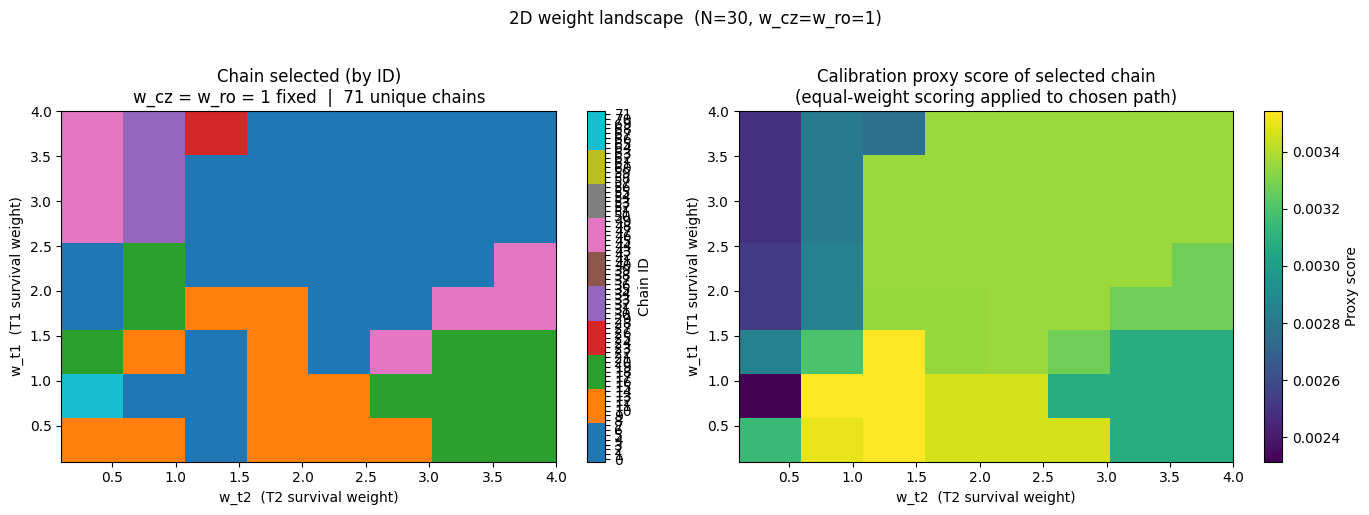

Saved → weight_landscape_2d.png


In [73]:
GRID_SIZE = 8
t1_range  = np.linspace(0.1, 4.0, GRID_SIZE)
t2_range  = np.linspace(0.1, 4.0, GRID_SIZE)

chain_ids      = {ch: i for i, ch in enumerate(chain_to_info.keys())}
grid_chain_id  = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
grid_proxy     = np.zeros((GRID_SIZE, GRID_SIZE))

for i, wt1 in enumerate(t1_range):
    for j, wt2 in enumerate(t2_range):
        w  = {'cz': 1.0, 'ro': 1.0, 't1': float(wt1), 't2': float(wt2)}
        ch = make_chain(w)
        cid   = chain_ids.get(ch, len(chain_to_info))
        score = chain_to_info.get(ch, {}).get(
            'proxy_score', chain_proxy_score(list(ch), mean_cz_ns))
        grid_chain_id[i, j] = cid
        grid_proxy[i, j]    = score

n_unique  = len(chain_to_info)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cmap_cat = plt.cm.get_cmap('tab10', n_unique + 1)
im1 = axes[0].imshow(grid_chain_id, cmap=cmap_cat,
                     vmin=-0.5, vmax=n_unique + 0.5,
                     origin='lower', aspect='auto',
                     extent=[t2_range[0], t2_range[-1], t1_range[0], t1_range[-1]])
axes[0].set_xlabel('w_t2  (T2 survival weight)')
axes[0].set_ylabel('w_t1  (T1 survival weight)')
axes[0].set_title(f'Chain selected (by ID)\nw_cz = w_ro = 1 fixed  |  {n_unique} unique chains')
plt.colorbar(im1, ax=axes[0], ticks=range(n_unique + 1)).set_label('Chain ID')

im2 = axes[1].imshow(grid_proxy, cmap='viridis',
                     origin='lower', aspect='auto',
                     extent=[t2_range[0], t2_range[-1], t1_range[0], t1_range[-1]])
axes[1].set_xlabel('w_t2  (T2 survival weight)')
axes[1].set_ylabel('w_t1  (T1 survival weight)')
axes[1].set_title('Calibration proxy score of selected chain\n(equal-weight scoring applied to chosen path)')
plt.colorbar(im2, ax=axes[1]).set_label('Proxy score')

plt.suptitle(
    f'2D weight landscape  (N={N_QUBITS}, w_cz=w_ro=1)',
    fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('weight_landscape_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved \u2192 weight_landscape_2d.png')

## 8. QPU batch evaluation

Build, transpile and submit one Z-basis W-state circuit per unique chain.
All jobs are submitted before any retrieval to minimise wall-clock time.
**Estimated cost:** ≤ 30 chains × 250 shots ≤ 7 500 shots total.

In [74]:
candidate_chains = list(chain_to_info.keys())
transpiled       = {}
jobs             = {}

# Transpile all circuits
for ch in candidate_chains:
    qc_z = get_circuit(CircuitType.WSTATE, N_QUBITS)
    qc_z.measure_all()
    qc_t = transpile(qc_z, backend=backend, initial_layout=list(ch),
                     routing_method='none', optimization_level=1)
    assert swap_count(qc_t) == 0, f'Unexpected SWAPs for chain {ch}'
    transpiled[ch] = qc_t

print(f'Transpiled {len(transpiled)} circuits (0 SWAPs each).')
print(f'Total shots: {len(transpiled)} x {EVAL_SHOTS} = {len(transpiled) * EVAL_SHOTS:,}')
print()

# Submit all jobs
for i, (ch, qc_t) in enumerate(transpiled.items()):
    job = backend.run(qc_t, shots=EVAL_SHOTS)
    jobs[ch] = job
    names_str = ' \u2192 '.join(chain_to_info[ch]['names'][:4]) + '\u2026'
    print(f'  [{i+1:2d}/{len(transpiled)}]  ID={chain_ids[ch]:2d}  '
          f'job={job.job_id()[:8]}\u2026  {names_str}')

print(f'\nAll {len(jobs)} jobs submitted.')

Transpiled 71 circuits (0 SWAPs each).
Total shots: 71 x 500 = 35,500

  [ 1/71]  ID= 0  job=019e0f00…  QB12 → QB11 → QB5 → QB1…
  [ 2/71]  ID= 1  job=019e0f00…  QB20 → QB12 → QB11 → QB5…
  [ 3/71]  ID= 2  job=019e0f00…  QB3 → QB4 → QB5 → QB11…
  [ 4/71]  ID= 3  job=019e0f00…  QB12 → QB11 → QB5 → QB1…
  [ 5/71]  ID= 4  job=019e0f00…  QB1 → QB5 → QB11 → QB12…
  [ 6/71]  ID= 5  job=019e0f00…  QB49 → QB53 → QB52 → QB48…
  [ 7/71]  ID= 6  job=019e0f00…  QB12 → QB11 → QB5 → QB1…
  [ 8/71]  ID= 7  job=019e0f00…  QB12 → QB11 → QB5 → QB1…
  [ 9/71]  ID= 8  job=019e0f00…  QB3 → QB4 → QB5 → QB11…
  [10/71]  ID= 9  job=019e0f00…  QB39 → QB38 → QB30 → QB22…
  [11/71]  ID=10  job=019e0f00…  QB49 → QB53 → QB52 → QB48…
  [12/71]  ID=11  job=019e0f00…  QB12 → QB11 → QB5 → QB1…
  [13/71]  ID=12  job=019e0f00…  QB12 → QB11 → QB5 → QB1…
  [14/71]  ID=13  job=019e0f00…  QB12 → QB11 → QB5 → QB1…
  [15/71]  ID=14  job=019e0f00…  QB12 → QB11 → QB5 → QB1…
  [16/71]  ID=15  job=019e0f00…  QB49 → QB53 → QB52 → 

## 9. Retrieve results and compute Z-fidelity

In [75]:
chain_fidelities = {}

hdr = f'{"ID":>4}  {"Z-fidelity":>12}  {"Proxy score":>12}  Chain (first 5 qubits)'
print(hdr)
print('-' * 70)

for ch, job in jobs.items():
    raw    = job.result().get_counts()
    counts = parse_counts(raw, N_QUBITS)
    fz     = z_fidelity(counts, N_QUBITS)
    chain_fidelities[ch] = fz
    info = chain_to_info[ch]
    head = ' \u2192 '.join(info['names'][:5]) + '\u2026'
    marker = ' \u2605' if ch == baseline_chain else ''
    print(f'  {chain_ids[ch]:2d}  {fz:>10.4f}    {info["proxy_score"]:>10.4e}  {head}{marker}')

print('\nAll results retrieved.  (\u2605 = equal-weight baseline chain)')

  ID    Z-fidelity   Proxy score  Chain (first 5 qubits)
----------------------------------------------------------------------
[05-10 01:09:48;I] Waiting for job 019e0f00-37e5-7331-8d84-1d2072dfe1d3 to finish...
   0      0.0800    3.3488e-03  QB12 → QB11 → QB5 → QB1 → QB2…
[05-10 01:09:49;I] Waiting for job 019e0f00-3abf-7632-acfe-3e39550b664a to finish...
   1      0.0600    3.0842e-03  QB20 → QB12 → QB11 → QB5 → QB1…
[05-10 01:09:51;I] Waiting for job 019e0f00-3ddb-7431-b88d-31f99dcab520 to finish...
   2      0.0660    3.2300e-03  QB3 → QB4 → QB5 → QB11 → QB12…
[05-10 01:09:55;I] Waiting for job 019e0f00-414b-7e90-b19c-f00b8217255c to finish...
   3      0.0860    3.5413e-03  QB12 → QB11 → QB5 → QB1 → QB2… ★
[05-10 01:09:56;I] Waiting for job 019e0f00-4533-7fc3-b84a-353fe7896baf to finish...
   4      0.0760    3.3569e-03  QB1 → QB5 → QB11 → QB12 → QB6…
[05-10 01:09:58;I] Waiting for job 019e0f00-4840-79e1-93db-595246a1055b to finish...
   5      0.2120    2.5246e-03  QB49 → QB53 

## 10. Identify optimal weights

Best chain  (Z-fidelity = 0.2120):
  QB49 → QB53 → QB52 → QB48 → QB42 → QB34 → QB26 → QB25 → QB24 → QB23 → QB15 → QB16 → QB8 → QB9 → QB3 → QB4 → QB5 → QB11 → QB12 → QB6 → QB7 → QB13 → QB14 → QB22 → QB30 → QB29 → QB37 → QB45 → QB51 → QB50

Weights that selected this chain:
  w_cz = 3.136
  w_ro = 0.859
  w_t1 = 1.920
  w_t2 = 0.271

Equal-weight chain fidelity : 0.0860
Optimal-weight fidelity     : 0.2120
Delta                       : +0.1260


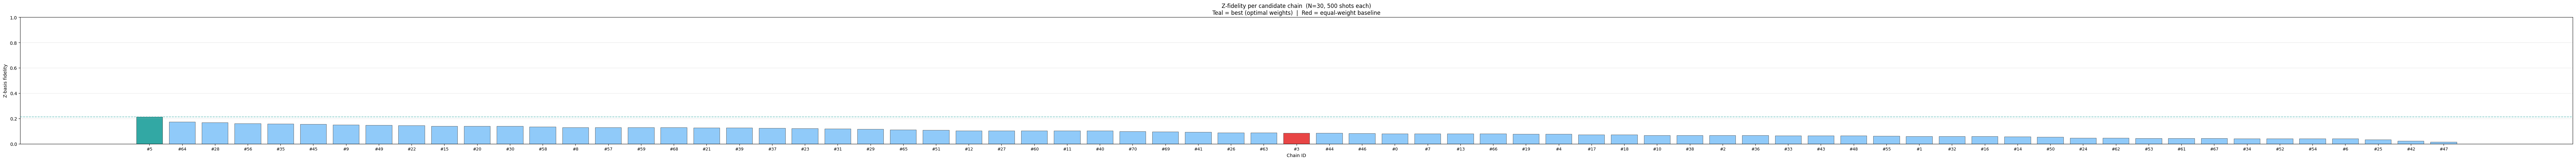

Saved → candidate_fidelities.png


In [76]:
best_chain    = max(chain_fidelities, key=chain_fidelities.get)
best_fidelity = chain_fidelities[best_chain]
best_info     = chain_to_info[best_chain]
best_weights  = best_info['weights']

print(f'Best chain  (Z-fidelity = {best_fidelity:.4f}):')
print('  ' + ' \u2192 '.join(best_info['names']))
print(f'\nWeights that selected this chain:')
for k, v in best_weights.items():
    print(f'  w_{k} = {v:.3f}')

# Baseline comparison
if prior_fid is not None:
    delta = best_fidelity - prior_fid
    print(f'\nPrior equal-weight fidelity : {prior_fid:.4f}  ({prior["metadata"]["shots"]} shots)')
    print(f'Optimal-weight fidelity     : {best_fidelity:.4f}  ({EVAL_SHOTS} shots)')
    print(f'Delta                       : {delta:+.4f}')
elif baseline_chain in chain_fidelities:
    baseline_fid = chain_fidelities[baseline_chain]
    print(f'\nEqual-weight chain fidelity : {baseline_fid:.4f}')
    print(f'Optimal-weight fidelity     : {best_fidelity:.4f}')
    print(f'Delta                       : {best_fidelity - baseline_fid:+.4f}')

# Bar chart: all candidates sorted by fidelity
sorted_items = sorted(chain_fidelities.items(), key=lambda x: -x[1])
bar_ids   = [chain_ids[ch] for ch, _ in sorted_items]
bar_fids  = [fz for _, fz in sorted_items]
bar_cols  = ['#32a8a4' if ch == best_chain else
             ('#e84545' if ch == baseline_chain else '#90CAF9')
             for ch, _ in sorted_items]

fig, ax = plt.subplots(figsize=(max(8, len(sorted_items) * 1.1), 5))
ax.bar(range(len(sorted_items)), bar_fids, color=bar_cols, edgecolor='#444', linewidth=0.6)
ax.set_xticks(range(len(sorted_items)))
ax.set_xticklabels([f'#{cid}' for cid in bar_ids], fontsize=9)
ax.set_xlabel('Chain ID')
ax.set_ylabel('Z-basis fidelity')
ax.set_ylim(0, 1.0)
ax.set_title(
    f'Z-fidelity per candidate chain  (N={N_QUBITS}, {EVAL_SHOTS} shots each)\n'
    f'Teal = best (optimal weights)  |  Red = equal-weight baseline')
ax.axhline(best_fidelity, color='#32a8a4', ls='--', lw=1.2, alpha=0.7)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('candidate_fidelities.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved \u2192 candidate_fidelities.png')

## 11. Nelder-Mead refinement — multi-restart

Run `NM_RESTARTS` independent Nelder-Mead optimisations, each starting from one of the
top-`NM_RESTARTS` grid-search candidates.  Multi-restart reduces the risk of getting
stuck in a local optimum of the discrete chain-selection landscape.

- Each **new** chain → 1 QPU job (`EVAL_SHOTS` shots)
- **Cached** chains (already measured in phase 2) → 0 extra shots
- Max new QPU calls: `NM_RESTARTS × NM_MAXITER` = {NM_RESTARTS × NM_MAXITER}
  (in practice far fewer because many weight perturbations select the same chain)

Multi-restart Nelder-Mead: 4 starting points × maxiter=30
Shots per new chain: 500  |  71 chains already cached

  Restart 1/4  [prev_run]  start_fidelity=0.1720  x0=[3.14 0.86 1.92 0.27]
    → fidelity=0.1720  evals=59  converged=True
  Restart 2/4  [grid_id=5]  start_fidelity=0.2120  x0=[3.14 0.86 1.92 0.27]
    → fidelity=0.1720  evals=59  converged=True
  Restart 3/4  [grid_id=64]  start_fidelity=0.1740  x0=[3.05 2.04 1.97 0.2 ]
    → fidelity=0.1300  evals=53  converged=True
  Restart 4/4  [grid_id=28]  start_fidelity=0.1680  x0=[2.14 0.5  3.35 0.3 ]
[05-10 01:11:40;I] Waiting for job 019e0f02-c121-7520-81e7-e7eac43288a2 to finish...
    new chain: fidelity=0.1200  w=['2.25', '0.50', '3.35', '0.30']
    → fidelity=0.1480  evals=47  converged=True

Post-refinement best:
  Weights  : {'cz': 3.1356956385876713, 'ro': 0.8590909606226735, 't1': 1.9202119145354333, 't2': 0.2708346865701922}
  Fidelity : 0.2120
  Total unique chains evaluated: 72


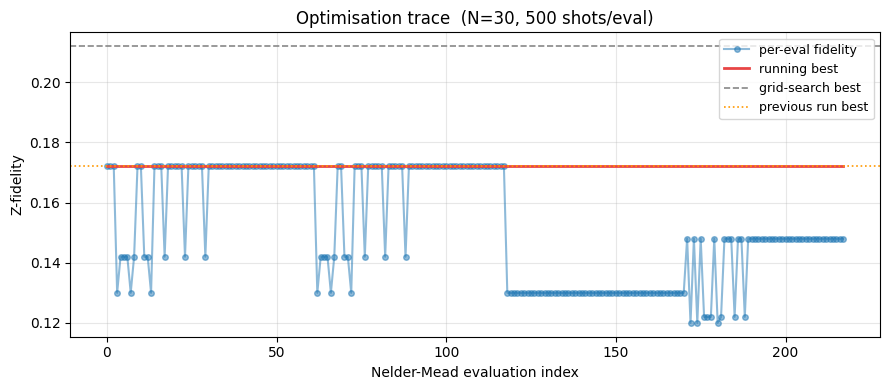

Saved → nm_optimization_trace.png


In [77]:
chain_cache = dict(chain_fidelities)
chain_cache.update(prev_chain_cache)   # merge previous run — no re-measurement needed
nm_history  = []

def objective(w_arr):
    w_arr   = np.abs(w_arr)
    weights = {'cz': w_arr[0], 'ro': w_arr[1], 't1': w_arr[2], 't2': w_arr[3]}
    ch = make_chain(weights)
    if ch in chain_cache:
        fz = chain_cache[ch]
    else:
        qc_z = get_circuit(CircuitType.WSTATE, N_QUBITS)
        qc_z.measure_all()
        qc_t = transpile(qc_z, backend=backend, initial_layout=list(ch),
                         routing_method='none', optimization_level=1)
        assert swap_count(qc_t) == 0
        job    = backend.run(qc_t, shots=EVAL_SHOTS)
        counts = parse_counts(job.result().get_counts(), N_QUBITS)
        fz     = z_fidelity(counts, N_QUBITS)
        chain_cache[ch] = fz
        print(f'    new chain: fidelity={fz:.4f}  w={[f"{v:.2f}" for v in w_arr]}')
    nm_history.append((w_arr.copy(), fz))
    return -fz

# Build starting-point list:
#   1. Previous run's optimal weights (if available) — highest priority
#   2. Top-NM_RESTARTS chains from the current grid search
nm_starts = []
if prev_best_weights is not None:
    nm_starts.append(('prev_run', prev_best_weights,
                       prev_best_fidelity if prev_best_fidelity > 0 else best_fidelity))

for ch, fid in sorted(chain_fidelities.items(), key=lambda x: -x[1])[:NM_RESTARTS]:
    nm_starts.append((f'grid_id={chain_ids[ch]}', chain_to_info[ch]['weights'], fid))

best_nm_fidelity = max(best_fidelity, prev_best_fidelity)
best_nm_weights  = best_weights if best_fidelity >= prev_best_fidelity else prev_best_weights

print(f'Multi-restart Nelder-Mead: {len(nm_starts)} starting points × maxiter={NM_MAXITER}')
print(f'Shots per new chain: {EVAL_SHOTS}  |  {len(chain_cache)} chains already cached\n')

for i, (label, sw, start_fid) in enumerate(nm_starts):
    x0 = np.array([sw['cz'], sw['ro'], sw['t1'], sw['t2']])
    print(f'  Restart {i+1}/{len(nm_starts)}  [{label}]  start_fidelity={start_fid:.4f}  x0={np.round(x0, 2)}')

    res = minimize(objective, x0, method='Nelder-Mead',
                   options={'maxiter': NM_MAXITER, 'xatol': 0.02, 'fatol': 0.001,
                            'adaptive': True})

    r_w  = {k: float(abs(v)) for k, v in zip(['cz', 'ro', 't1', 't2'], res.x)}
    r_ch = make_chain(r_w)
    r_fz = chain_cache.get(r_ch, -res.fun)
    print(f'    → fidelity={r_fz:.4f}  evals={res.nfev}  converged={res.success}')

    if r_fz > best_nm_fidelity:
        best_nm_fidelity = r_fz
        best_nm_weights  = r_w
        print(f'    ✓ new best!')

refined_weights  = best_nm_weights
refined_fidelity = best_nm_fidelity

print(f'\nPost-refinement best:')
print(f'  Weights  : {refined_weights}')
print(f'  Fidelity : {refined_fidelity:.4f}')
print(f'  Total unique chains evaluated: {len(chain_cache)}')

# Optimisation trace
if nm_history:
    running_best = np.maximum.accumulate([fz for _, fz in nm_history])
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot([fz for _, fz in nm_history], 'o-', alpha=0.5, markersize=4, label='per-eval fidelity')
    ax.plot(running_best, lw=2, color='#e84545', label='running best')
    ax.axhline(best_fidelity, ls='--', color='#888', lw=1.2, label='grid-search best')
    if prev_best_fidelity > 0:
        ax.axhline(prev_best_fidelity, ls=':', color='#ff9800', lw=1.2, label='previous run best')
    ax.set_xlabel('Nelder-Mead evaluation index')
    ax.set_ylabel('Z-fidelity')
    ax.set_title(f'Optimisation trace  (N={N_QUBITS}, {EVAL_SHOTS} shots/eval)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('nm_optimization_trace.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → nm_optimization_trace.png')

final_weights  = refined_weights if refined_fidelity > best_fidelity else best_weights
final_fidelity = max(refined_fidelity, best_fidelity)

## 12. X-basis witness — optimal vs equal-weight baseline

Submit X-basis (Hadamard + measure) circuits for the optimal chain and the baseline chain.
Compare ⟨W⟩ and the full correlator matrix ⟨Xi Xj⟩ side-by-side.

Submitting X-basis jobs (500 shots each) ...
  optimal  job: 019e0f02…
  baseline job: 019e0f02…
[05-10 01:11:48;I] Waiting for job 019e0f02-dd2f-7bf3-9991-1d84850c9712 to finish...
[05-10 01:11:50;I] Waiting for job 019e0f02-e22b-7281-af57-c6bcb734cec3 to finish...

                        Z-fidelity     X-witness     ideal X
--------------------------------------------------------------
Equal weights               0.0860        0.5066      0.0667
Optimal weights             0.2120        0.5766      0.0667


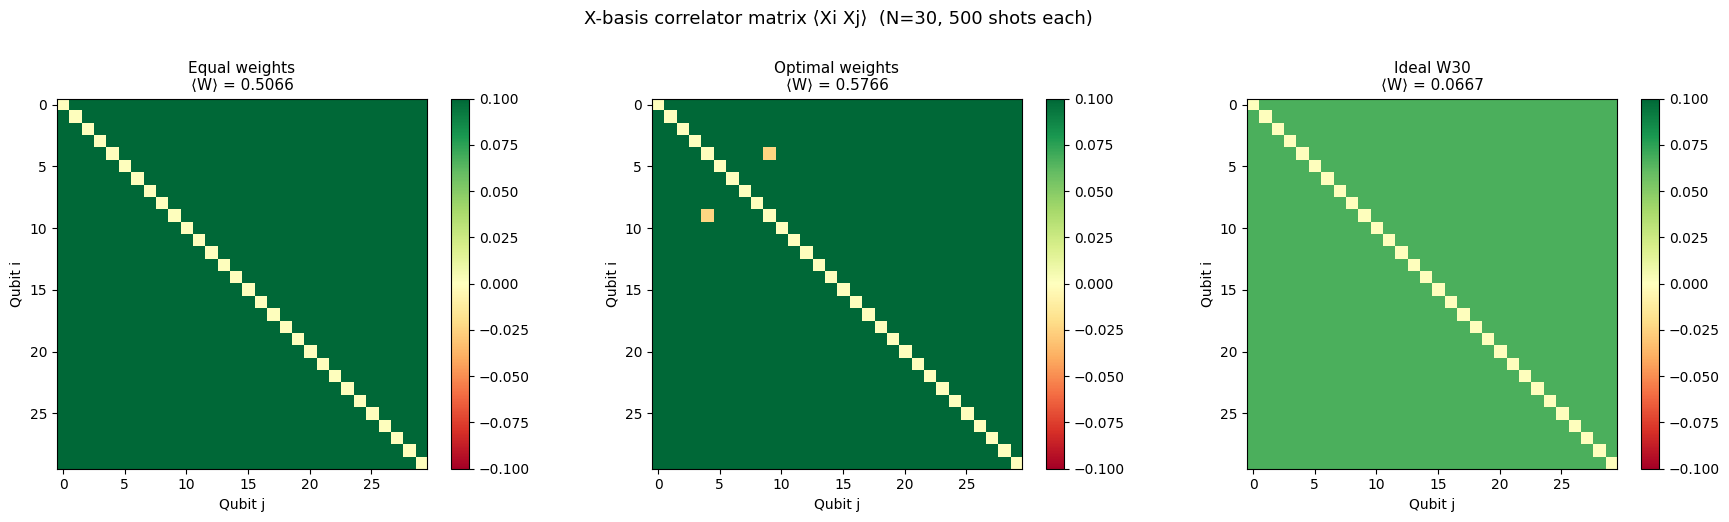

Saved → x_witness_comparison.png


In [78]:
try:
    _fw = final_weights
except NameError:
    _fw = best_weights

opt_chain_x = make_chain(_fw)

def build_x_circuit(ch, n):
    qc = get_circuit(CircuitType.WSTATE, n)
    qc.h(range(n))
    qc.measure_all()
    return transpile(qc, backend=backend, initial_layout=list(ch),
                     routing_method='none', optimization_level=1)

qc_x_opt  = build_x_circuit(opt_chain_x,    N_QUBITS)
qc_x_base = build_x_circuit(baseline_chain, N_QUBITS)
assert swap_count(qc_x_opt) == 0 and swap_count(qc_x_base) == 0

print(f'Submitting X-basis jobs ({EVAL_SHOTS} shots each) ...')
job_x_opt  = backend.run(qc_x_opt,  shots=EVAL_SHOTS)
job_x_base = backend.run(qc_x_base, shots=EVAL_SHOTS)
print(f'  optimal  job: {job_x_opt.job_id()[:8]}…')
print(f'  baseline job: {job_x_base.job_id()[:8]}…')

counts_x_opt  = parse_counts(job_x_opt.result().get_counts(),  N_QUBITS)
counts_x_base = parse_counts(job_x_base.result().get_counts(), N_QUBITS)

wit_opt  = x_witness(counts_x_opt,  N_QUBITS)
wit_base = x_witness(counts_x_base, N_QUBITS)
ideal_w  = 2.0 / N_QUBITS

print(f'\n{"":20}  {"Z-fidelity":>12}  {"X-witness":>12}  {"ideal X":>10}')
print('-' * 62)
fz_base_str = f'{chain_fidelities.get(baseline_chain, float("nan")):>12.4f}'
fz_opt_str  = f'{chain_fidelities.get(opt_chain_x,    float("nan")):>12.4f}'
print(f'{"Equal weights":20}  {fz_base_str}  {wit_base:>12.4f}  {ideal_w:>10.4f}')
print(f'{"Optimal weights":20}  {fz_opt_str}  {wit_opt:>12.4f}  {ideal_w:>10.4f}')

# Correlator matrix heatmaps
C_opt  = x_correlator_matrix(counts_x_opt,  N_QUBITS)
C_base = x_correlator_matrix(counts_x_base, N_QUBITS)
ideal_mat = np.full((N_QUBITS, N_QUBITS), ideal_w)
np.fill_diagonal(ideal_mat, 0.0)

vmax = ideal_w * 1.5
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, mat, title in [
        (axes[0], C_base, f'Equal weights\n⟨W⟩ = {wit_base:.4f}'),
        (axes[1], C_opt,  f'Optimal weights\n⟨W⟩ = {wit_opt:.4f}'),
        (axes[2], ideal_mat, f'Ideal W{N_QUBITS}\n⟨W⟩ = {ideal_w:.4f}')]:
    im = ax.imshow(mat, cmap='RdYlGn', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Qubit j')
    ax.set_ylabel('Qubit i')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(
    f'X-basis correlator matrix ⟨Xi Xj⟩  (N={N_QUBITS}, {EVAL_SHOTS} shots each)',
    fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('x_witness_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → x_witness_comparison.png')

## 12. Cross-validation across qubit counts

Apply the optimal weights to N ∈ {10, 15, 20, 25} and compare against the
equal-weight baseline from `qubit_scaling_results.json`.

All jobs are submitted before retrieval to minimise latency.

In [79]:
CROSS_VAL_N   = [20, 22, 24, 26, 28, 30]   # fine-grained sweep from 20 → 30 on Emerald
try:
    opt_weights = final_weights
except NameError:
    opt_weights = best_weights

print(f'Cross-validating with weights: {opt_weights}\n')

xval_jobs   = {}   # n → (job_z, job_x)
xval_chains = {}

for n in CROSS_VAL_N:
    ch = make_chain(opt_weights, n=n)
    xval_chains[n] = ch

    qc_z = get_circuit(CircuitType.WSTATE, n); qc_z.measure_all()
    qc_z_t = transpile(qc_z, backend=backend, initial_layout=list(ch),
                       routing_method='none', optimization_level=1)
    assert swap_count(qc_z_t) == 0

    qc_x = get_circuit(CircuitType.WSTATE, n); qc_x.h(range(n)); qc_x.measure_all()
    qc_x_t = transpile(qc_x, backend=backend, initial_layout=list(ch),
                       routing_method='none', optimization_level=1)
    assert swap_count(qc_x_t) == 0

    job_z = backend.run(qc_z_t, shots=EVAL_SHOTS)
    job_x = backend.run(qc_x_t, shots=EVAL_SHOTS)
    xval_jobs[n] = (job_z, job_x)

    names = [backend.index_to_qubit_name(q) for q in ch]
    print(f'N={n:2d}: {" → ".join(names[:4])}…'
          f'  Z={job_z.job_id()[:8]}…  X={job_x.job_id()[:8]}…')

print(f'\nAll {len(xval_jobs) * 2} cross-validation jobs submitted.')

Cross-validating with weights: {'cz': 3.1356956385876713, 'ro': 0.8590909606226735, 't1': 1.9202119145354333, 't2': 0.2708346865701922}

N=20: QB49 → QB53 → QB52 → QB48…  Z=019e0f02…  X=019e0f02…
N=22: QB49 → QB53 → QB52 → QB48…  Z=019e0f03…  X=019e0f03…
N=24: QB49 → QB53 → QB52 → QB48…  Z=019e0f03…  X=019e0f03…
N=26: QB49 → QB53 → QB52 → QB48…  Z=019e0f03…  X=019e0f03…
N=28: QB49 → QB53 → QB52 → QB48…  Z=019e0f03…  X=019e0f03…
N=30: QB49 → QB53 → QB52 → QB48…  Z=019e0f03…  X=019e0f03…

All 12 cross-validation jobs submitted.


In [80]:
xval_fids_opt    = {}
xval_witness_opt = {}
xval_counts_x    = {}   # keep X-basis counts for correlator matrix later

print(f'{"N":>4}  {"Z-fid (opt)":>12}  {"X-wit (opt)":>12}  {"Z-fid (base)":>14}  {"ideal X":>9}')
print('-' * 60)

def _baseline_fid(n):
    if prior is not None:
        reps = prior['results'].get(str(n), [])
        if reps:
            return float(np.mean([r['fidelity_z'] for r in reps]))
    if n == N_QUBITS and baseline_chain in chain_fidelities:
        return chain_fidelities[baseline_chain]
    return None

baseline_fids_xval = []

for n in CROSS_VAL_N:
    job_z, job_x = xval_jobs[n]
    counts_z = parse_counts(job_z.result().get_counts(), n)
    counts_x = parse_counts(job_x.result().get_counts(), n)
    xval_counts_x[n] = counts_x
    fz = z_fidelity(counts_z, n)
    wx = x_witness(counts_x, n)
    xval_fids_opt[n]    = fz
    xval_witness_opt[n] = wx
    bf = _baseline_fid(n)
    baseline_fids_xval.append(bf)
    bf_str = f'{bf:.4f}' if bf is not None else 'N/A'
    print(f'{n:>4}  {fz:>12.4f}  {wx:>12.4f}  {bf_str:>14}  {2/n:>9.4f}')

print('\nAll cross-validation results retrieved.')

   N   Z-fid (opt)   X-wit (opt)    Z-fid (base)    ideal X
------------------------------------------------------------
[05-10 01:12:04;I] Waiting for job 019e0f02-fd1f-78b1-b631-5051ec7bae68 to finish...
[05-10 01:12:06;I] Waiting for job 019e0f02-fff2-76b0-b0da-f8a8c5996a9a to finish...
  20        0.4000        0.6262          0.4030     0.1000
[05-10 01:12:07;I] Waiting for job 019e0f03-0351-7cd3-944a-062107e0cf4f to finish...
[05-10 01:12:08;I] Waiting for job 019e0f03-0764-7063-bf04-5647f774eb22 to finish...
  22        0.3280        0.6336             N/A     0.0909
[05-10 01:12:10;I] Waiting for job 019e0f03-0a97-7ef3-81b0-3ffd4434010f to finish...
[05-10 01:12:11;I] Waiting for job 019e0f03-0d6e-7882-a041-cc237c0a093e to finish...
  24        0.2640        0.6267             N/A     0.0833
[05-10 01:12:13;I] Waiting for job 019e0f03-107b-76a0-9aa3-be5ba7db332b to finish...
[05-10 01:12:14;I] Waiting for job 019e0f03-1447-7693-956a-fe68430a47fa to finish...
  26        0.2200 

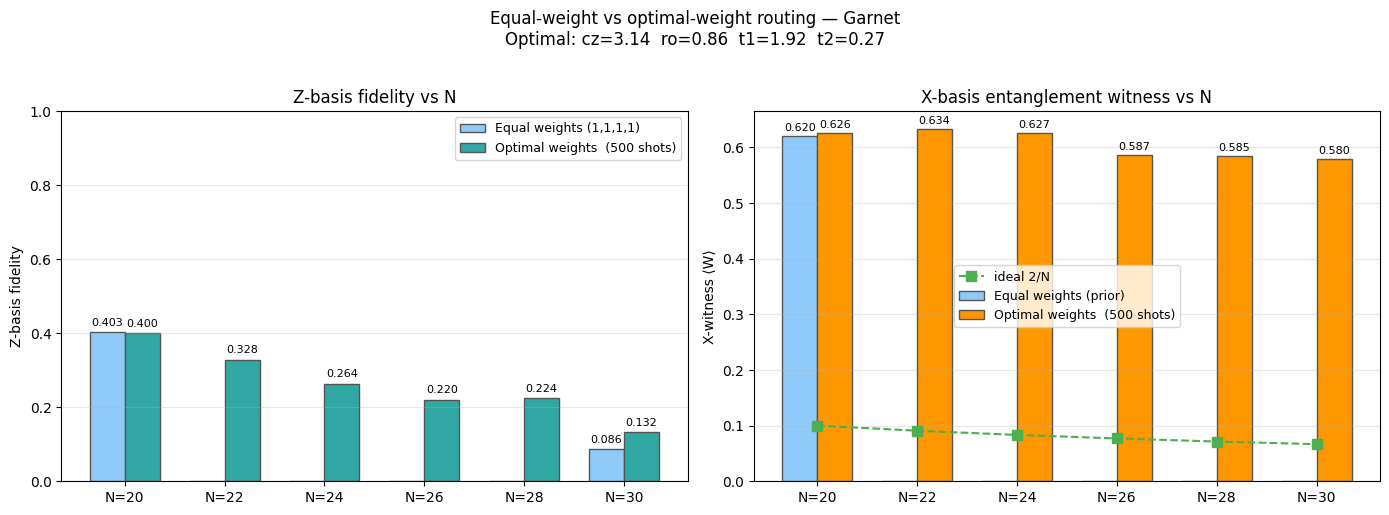

Saved → cross_validation_comparison.png


In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x     = np.arange(len(CROSS_VAL_N))
width = 0.35

# ── Z-fidelity panel ────────────────────────────────────────────────────────
ax = axes[0]
base_z = [bf if bf is not None else 0.0 for bf in baseline_fids_xval]
opt_z  = [xval_fids_opt[n] for n in CROSS_VAL_N]
bars1 = ax.bar(x - width/2, base_z, width, label='Equal weights (1,1,1,1)',
               color='#90CAF9', edgecolor='#555')
bars2 = ax.bar(x + width/2, opt_z,  width, label=f'Optimal weights  ({EVAL_SHOTS} shots)',
               color='#32a8a4', edgecolor='#555')
ax.set_xticks(x); ax.set_xticklabels([f'N={n}' for n in CROSS_VAL_N])
ax.set_ylabel('Z-basis fidelity'); ax.set_ylim(0, 1.0)
ax.set_title('Z-basis fidelity vs N')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.012,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

# ── X-witness panel ─────────────────────────────────────────────────────────
ax = axes[1]
opt_wx   = [xval_witness_opt[n] for n in CROSS_VAL_N]
ideal_wx = [2.0/n for n in CROSS_VAL_N]
# Pull prior X-witness if available
prior_wx = []
for n in CROSS_VAL_N:
    reps = (prior or {}).get('results', {}).get(str(n), [])
    prior_wx.append(float(np.mean([r['witness_x'] for r in reps])) if reps else None)
base_wx = [v if v is not None else 0.0 for v in prior_wx]

bars3 = ax.bar(x - width/2, base_wx, width, label='Equal weights (prior)',
               color='#90CAF9', edgecolor='#555')
bars4 = ax.bar(x + width/2, opt_wx, width, label=f'Optimal weights  ({EVAL_SHOTS} shots)',
               color='#FF9800', edgecolor='#555')
ax.plot(x, ideal_wx, 's--', color='#4CAF50', markersize=7, lw=1.5, label='ideal 2/N')
ax.set_xticks(x); ax.set_xticklabels([f'N={n}' for n in CROSS_VAL_N])
ax.set_ylabel('X-witness ⟨W⟩'); ax.set_ylim(0, None)
ax.set_title('X-basis entanglement witness vs N')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)
for bar in list(bars3) + list(bars4):
    h = bar.get_height()
    if h > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

try:
    ow = opt_weights
except NameError:
    ow = best_weights
plt.suptitle(
    f'Equal-weight vs optimal-weight routing — Garnet\n'
    f'Optimal: cz={ow["cz"]:.2f}  ro={ow["ro"]:.2f}  t1={ow["t1"]:.2f}  t2={ow["t2"]:.2f}',
    fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('cross_validation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → cross_validation_comparison.png')

No N in [20, 22, 24, 26, 28, 30] achieved Z-fidelity > 0.5.
Showing correlator matrix for the best available N instead.


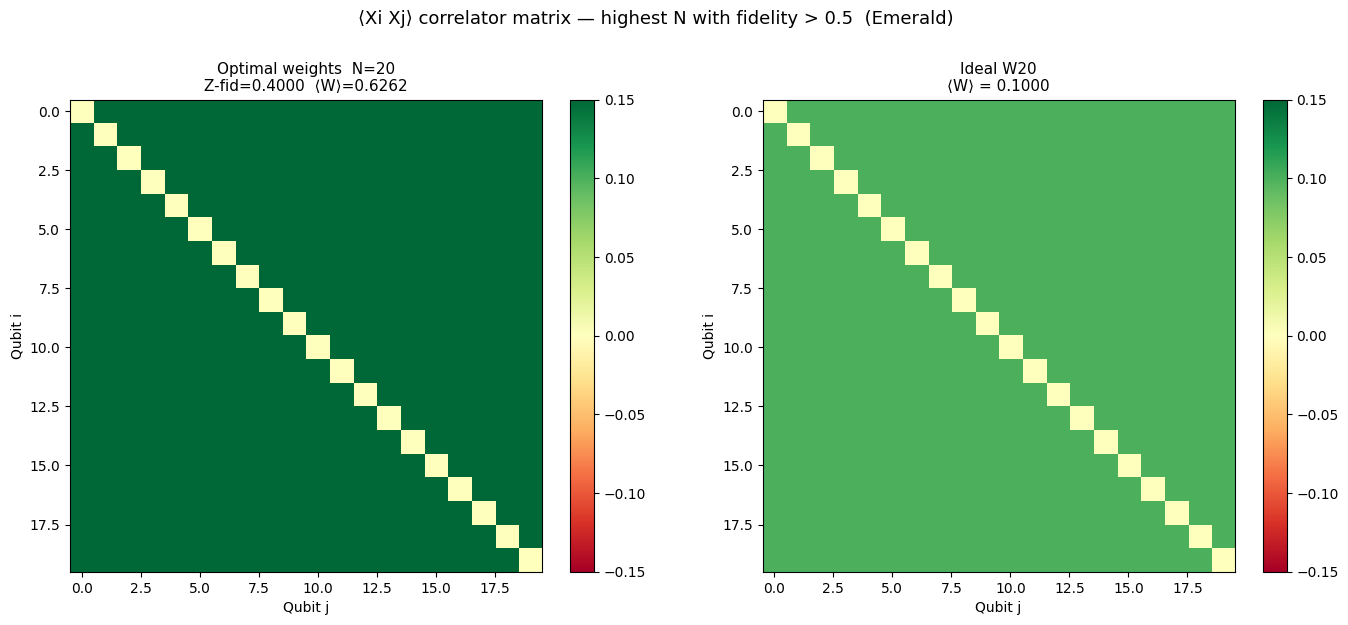

Saved → correlator_matrix_N20.png


In [82]:
# Correlator matrix for the highest N that still achieves Z-fidelity > 0.5
FIDELITY_THRESHOLD = 0.5
above = [n for n in CROSS_VAL_N if xval_fids_opt[n] > FIDELITY_THRESHOLD]

if not above:
    print(f'No N in {CROSS_VAL_N} achieved Z-fidelity > {FIDELITY_THRESHOLD}.')
    print('Showing correlator matrix for the best available N instead.')
    best_n = max(CROSS_VAL_N, key=lambda n: xval_fids_opt[n])
else:
    best_n = max(above)
    print(f'Highest N with Z-fidelity > {FIDELITY_THRESHOLD}: N={best_n}'
          f'  (fid={xval_fids_opt[best_n]:.4f}  witness={xval_witness_opt[best_n]:.4f})')

C_best   = x_correlator_matrix(xval_counts_x[best_n], best_n)
ideal_w  = 2.0 / best_n
ideal_mat = np.full((best_n, best_n), ideal_w)
np.fill_diagonal(ideal_mat, 0.0)

vmax = ideal_w * 1.5
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, mat, title in [
        (axes[0], C_best,   f'Optimal weights  N={best_n}\n'
                            f'Z-fid={xval_fids_opt[best_n]:.4f}  ⟨W⟩={xval_witness_opt[best_n]:.4f}'),
        (axes[1], ideal_mat, f'Ideal W{best_n}\n⟨W⟩ = {ideal_w:.4f}')]:
    im = ax.imshow(mat, cmap='RdYlGn', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Qubit j')
    ax.set_ylabel('Qubit i')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(
    f'⟨Xi Xj⟩ correlator matrix — highest N with fidelity > {FIDELITY_THRESHOLD}  (Emerald)',
    fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'correlator_matrix_N{best_n}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → correlator_matrix_N{best_n}.png')

## 13. Save results

In [83]:
try:
    _ow = final_weights
except NameError:
    _ow = best_weights

# ── helpers ──────────────────────────────────────────────────────────────────
def _chain_entry(ch, fz=None, wx=None):
    info = chain_to_info.get(ch, {})
    return {
        'names':       info.get('names', [backend.index_to_qubit_name(q) for q in ch]),
        'indices':     list(ch),
        'fidelity_z':  fz,
        'witness_x':   wx,
        'proxy_score': info.get('proxy_score'),
    }

# ── assemble output ───────────────────────────────────────────────────────────
output = {
    'metadata': {
        'timestamp':        datetime.datetime.now(datetime.timezone.utc).isoformat(),
        'backend':          backend.name,
        'num_qubits':       backend.num_qubits,
        'target_n':         N_QUBITS,
        'eval_shots':       EVAL_SHOTS,
        'beam_width':       BEAM_WIDTH,
        'n_weight_samples': N_WEIGHT_SAMPLES,
        'n_unique_chains':  len(chain_to_info),
    },

    # ── weights ───────────────────────────────────────────────────────────────
    'optimal_weights':  _ow,
    'baseline_weights': EQ_WEIGHTS,

    # ── grid-search candidates (all unique chains, sorted by fidelity) ────────
    'candidates': [
        {
            **_chain_entry(ch, fz=chain_fidelities[ch]),
            'chain_id':              chain_ids[ch],
            'representative_weights': chain_to_info[ch]['weights'],
        }
        for ch in sorted(chain_fidelities, key=lambda c: -chain_fidelities[c])
    ],

    # ── optimal chain — Z + X basis ───────────────────────────────────────────
    'optimal_chain': {
        **_chain_entry(make_chain(_ow),
                       fz=chain_fidelities.get(make_chain(_ow)),
                       wx=locals().get('wit_opt')),
        'weights': _ow,
    },

    # ── baseline chain — Z + X basis ─────────────────────────────────────────
    'baseline_chain': _chain_entry(
        baseline_chain,
        fz=chain_fidelities.get(baseline_chain),
        wx=locals().get('wit_base'),
    ),

    # ── cross-validation ──────────────────────────────────────────────────────
    'cross_validation': {
        str(n): {
            'fidelity_z_optimal':  xval_fids_opt[n],
            'witness_x_optimal':   xval_witness_opt[n],
            'fidelity_z_baseline': _baseline_fid(n),
            'ideal_witness_x':     2.0 / n,
            'chain_names':         [backend.index_to_qubit_name(q) for q in xval_chains[n]],
            'chain_indices':       list(xval_chains[n]),
        }
        for n in CROSS_VAL_N
    },

    # ── highest-N correlator matrix ───────────────────────────────────────────
    'best_n_above_threshold': {
        'n':                best_n,
        'fidelity_z':       xval_fids_opt[best_n],
        'witness_x':        xval_witness_opt[best_n],
        'ideal_witness_x':  2.0 / best_n,
        'fidelity_threshold': FIDELITY_THRESHOLD,
        'correlator_matrix': x_correlator_matrix(xval_counts_x[best_n], best_n).tolist(),
    },

    # ── Nelder-Mead trace ─────────────────────────────────────────────────────
    'nm_trace': [
        {'weights': w.tolist(), 'fidelity_z': fz}
        for w, fz in nm_history
    ] if 'nm_history' in dir() and nm_history else [],
}

with open(RESULTS_FILE, 'w') as f:
    json.dump(output, f, indent=2)

print(f'Saved → {RESULTS_FILE}')
print(f'\nSummary:')
print(f'  Unique chains explored    : {len(chain_to_info)}')
print(f'  Optimal weights           : {_ow}')
print(f'  Best grid fidelity        : {max(chain_fidelities.values()):.4f}  (N={N_QUBITS}, {EVAL_SHOTS} shots)')
if prior_fid is not None:
    print(f'  vs equal-weight prior     : {prior_fid:.4f}  ({prior["metadata"]["shots"]} shots)')
print(f'  Highest N above threshold : N={best_n}  (fid={xval_fids_opt[best_n]:.4f}  wit={xval_witness_opt[best_n]:.4f})')
print(f'  Nelder-Mead evaluations   : {len(nm_history) if "nm_history" in dir() else 0}')

Saved → routing_coefficient_optimization_results_emerald_2.json

Summary:
  Unique chains explored    : 71
  Optimal weights           : {'cz': 3.1356956385876713, 'ro': 0.8590909606226735, 't1': 1.9202119145354333, 't2': 0.2708346865701922}
  Best grid fidelity        : 0.2120  (N=30, 500 shots)
  Highest N above threshold : N=20  (fid=0.4000  wit=0.6262)
  Nelder-Mead evaluations   : 218


## 14. Readout-mitigated run — N=22, optimal weights

Calibration circuits use just 100 shots each (enough for per-qubit readout estimates).
The W-state circuit gets 500 shots for better statistics.

**Cost: 2x100 + 500 = 700 shots total.**

In [84]:
from qiskit import QuantumCircuit

MIT_N      = 22
CAL_SHOTS  = 100   # calibration only needs rough per-qubit estimates
WSTATE_SHOTS = 250  # W-state gets the bulk of the shot budget

# Optimal weights from prior Nelder-Mead optimization
opt_w = {"cz": 3.1357, "ro": 0.8591, "t1": 1.9202, "t2": 0.2708}

# Best chain for N=22
mit_chain = make_chain(opt_w, n=MIT_N)
mit_names  = [backend.index_to_qubit_name(q) for q in mit_chain]
print(f"N={MIT_N} chain: {" -> ".join(mit_names)}")
print(f"Calibration: {CAL_SHOTS} shots each | W-state: {WSTATE_SHOTS} shots")
print(f"Total: {2*CAL_SHOTS + WSTATE_SHOTS} shots")
print()

# Calibration circuit |0...0>
qc_cal0 = QuantumCircuit(MIT_N)
qc_cal0.measure_all()
qc_cal0_t = transpile(qc_cal0, backend=backend, initial_layout=list(mit_chain),
                      routing_method="none", optimization_level=0)

# Calibration circuit |1...1>
qc_cal1 = QuantumCircuit(MIT_N)
qc_cal1.x(range(MIT_N))
qc_cal1.measure_all()
qc_cal1_t = transpile(qc_cal1, backend=backend, initial_layout=list(mit_chain),
                      routing_method="none", optimization_level=0)

# W-state Z-basis circuit
qc_w = get_circuit(CircuitType.WSTATE, MIT_N)
qc_w.measure_all()
qc_w_t = transpile(qc_w, backend=backend, initial_layout=list(mit_chain),
                   routing_method="none", optimization_level=1)
assert swap_count(qc_w_t) == 0

# Submit all three before waiting on any
print("Submitting jobs ...")
job_cal0 = backend.run(qc_cal0_t, shots=CAL_SHOTS)
job_cal1 = backend.run(qc_cal1_t, shots=CAL_SHOTS)
job_w    = backend.run(qc_w_t,    shots=WSTATE_SHOTS)
print(f"  cal|0>  ({CAL_SHOTS} shots): {job_cal0.job_id()}")
print(f"  cal|1>  ({CAL_SHOTS} shots): {job_cal1.job_id()}")
print(f"  W-state ({WSTATE_SHOTS} shots): {job_w.job_id()}")

# Retrieve
counts_cal0 = parse_counts(job_cal0.result().get_counts(), MIT_N)
counts_cal1 = parse_counts(job_cal1.result().get_counts(), MIT_N)
counts_w    = parse_counts(job_w.result().get_counts(),    MIT_N)

# Per-qubit readout assignment probabilities
total0 = sum(counts_cal0.values())
total1 = sum(counts_cal1.values())
p00 = np.zeros(MIT_N)  # P(read 0 | prepared 0)
p11 = np.zeros(MIT_N)  # P(read 1 | prepared 1)
for bits, cnt in counts_cal0.items():
    for k, b in enumerate(reversed(bits)):
        if b == "0":
            p00[k] += cnt / total0
for bits, cnt in counts_cal1.items():
    for k, b in enumerate(reversed(bits)):
        if b == "1":
            p11[k] += cnt / total1

print(f"Readout fidelities (mean over {MIT_N} qubits):")
print(f"  mean P(0|0) = {np.mean(p00):.4f}  std = {np.std(p00):.4f}")
print(f"  mean P(1|1) = {np.mean(p11):.4f}  std = {np.std(p11):.4f}")

# Analytical readout correction for Z-fidelity.
# For W-state bitstring |e_k>, readout attenuation = p11[k] * prod_{j!=k} p00[j].
# Average over all N terms gives the suppression factor.
readout_factor = sum(p11[k] * np.prod(p00) / p00[k] for k in range(MIT_N)) / MIT_N

fz_raw       = z_fidelity(counts_w, MIT_N)
fz_mitigated = min(fz_raw / readout_factor, 1.0)

print(f"Readout suppression factor : {readout_factor:.4f}")
print(f"Z-fidelity  raw            : {fz_raw:.4f}  ({WSTATE_SHOTS} shots)")
print(f"Z-fidelity  mitigated      : {fz_mitigated:.4f}")
print(f"Improvement                : {fz_mitigated - fz_raw:+.4f}")
print(f"Target Z > 0.5 with N={MIT_N}: {'ACHIEVED' if fz_mitigated > 0.5 else 'not reached'}")


N=22 chain: QB49 -> QB53 -> QB52 -> QB48 -> QB42 -> QB34 -> QB26 -> QB25 -> QB24 -> QB16 -> QB8 -> QB9 -> QB3 -> QB4 -> QB5 -> QB11 -> QB12 -> QB6 -> QB7 -> QB13 -> QB14 -> QB22
Calibration: 100 shots each | W-state: 250 shots
Total: 450 shots

Submitting jobs ...
  cal|0>  (100 shots): 019e0f03-6d24-7ea2-bad9-5d77c52495dd
  cal|1>  (100 shots): 019e0f03-70ee-77b0-b26b-445968d5ebd7
  W-state (250 shots): 019e0f03-740a-7b21-9be4-d2955aba8ee4
[05-10 01:12:26;I] Waiting for job 019e0f03-6d24-7ea2-bad9-5d77c52495dd to finish...
[05-10 01:12:31;I] Waiting for job 019e0f03-70ee-77b0-b26b-445968d5ebd7 to finish...
[05-10 01:12:33;I] Waiting for job 019e0f03-740a-7b21-9be4-d2955aba8ee4 to finish...
Readout fidelities (mean over 22 qubits):
  mean P(0|0) = 0.9959  std = 0.0083
  mean P(1|1) = 0.9745  std = 0.0248
Readout suppression factor : 0.8935
Z-fidelity  raw            : 0.3600  (250 shots)
Z-fidelity  mitigated      : 0.4029
Improvement                : +0.0429
Target Z > 0.5 with N=22: 